In [1]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import warnings 
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        pass
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
train = pd.read_parquet('/kaggle/input/datasets/analyticgentleman/gold-data/train_data/').set_index('customer_ID')
train.head(2)

P_2_mean   P_2_min  \
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.933824  0.868580   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.899820  0.861109   

                                                     P_2_max   P_2_std  \
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.960384  0.024194   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.929122  0.022119   

                                                    P_2_last    P_2_sum  \
customer_ID                                                               
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.934745  12.139710   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.880519  11.697655   

                                                    D_39_mean  D_39_min  \
customer_ID                                                               
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...   0.230769       0.0   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...   7.153846       0.0   

                                                    D_39_max  D_39_std  \
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...       3.0  0.832050   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...      19.0  6.743468   

                                                    D_39_last  D_39_sum  \
customer_ID                                                               
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...        0.0       3.0   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...        6.0      93.0   

                                                    B_1_mean   B_1_min  \
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.012007  0.001930   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.025654  0.006711   

                                                     B_1_max   B_1_std  \
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.021655  0.006547   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.109644  0.027756   

                                                    B_1_last   B_1_sum  \
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.009382  0.156094   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.034684  0.333500   

                                                    B_2_mean   B_2_min  \
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  1.005086  1.000242   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.991083  0.819772   

                                                     B_2_max   B_2_std  \
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  1.009672  0.003222   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  1.008534  0.051531   

                                                    B_2_last    B_2_sum  \
customer_ID                                                               
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  1.007647  13.066114   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  1.004028  12.884082   

                                                    R_1_mean   R_1_min  \
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.004509  0.000263   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.006246  0.001023   

                                                     R_1_max   R_1_std  \
customer_ID                                                              
0000099d6bd597052cdcda90ffa

In [3]:
print(train.shape)
print(train["target"].value_counts())

(458913, 2600)
target
0    340085
1    118828
Name: count, dtype: int64


Insight: There are total 458913 customers in the training data.
Out of them, around 75% i.e. 3.4 Lakhs are non-defaulters and have paid the dues in time.
The rest 118828 i.e. around 25% are defaulters.

As we already know that the negative class has been sub-sampled at 5%, that means that 95% of non-defaulters were removed from the orignal data to generate this dataset. The orignal amount of non-defaulters will be much more.

## Pearson Correlation with target.

In [4]:
target = train["target"]
corr = train.corrwith(target).drop("target").abs().sort_values(ascending=False)

In [5]:
print(corr.head(20))

P_2_last           0.667293
P_2_last3_mean     0.658768
P_2_last6_mean     0.647145
P_2_min            0.635854
P_2_ym_rank        0.632973
P_2_last3_sum      0.630699
P_2_mean           0.627100
D_48_last          0.612357
D_48_last3_mean    0.609655
D_44_ym_rank       0.603370
D_48_last6_mean    0.599996
P_2_last6_sum      0.599608
P_2_max            0.594159
D_48_ym_rank       0.588142
D_48_last3_sum     0.585575
D_48_mean          0.579514
R_1_std            0.573124
B_2_last3_mean     0.567155
B_2_last3_sum      0.567007
D_48_last6_sum     0.565457
dtype: float64


## AUC Correlation(more suitable for rank-based AMEX metric).

In [6]:
target = train["target"].values

auc_corr = pd.Series({
    c: abs(roc_auc_score(
        target,
        np.nan_to_num(train[c].values, nan=np.nanmedian(train[c].values))
    ) - 0.5)
    for c in train.columns if c != "target"
}).sort_values(ascending=False)

In [7]:
auc_corr.head(20)

P_2_ym_rank        0.416090
P_2_last           0.416090
P_2_last3_mean     0.412804
P_2_last6_mean     0.407885
P_2_min            0.402168
P_2_last3_sum      0.401516
P_2_mean           0.398983
P_2_last6_sum      0.386395
P_2_max            0.379471
D_48_last3_mean    0.372035
D_48_ym_rank       0.371926
D_48_last          0.371926
D_48_last6_mean    0.368465
D_48_mean          0.360263
P_2_sum            0.359389
B_2_last3_sum      0.354842
B_2_last3_mean     0.353338
B_2_last6_sum      0.351450
D_48_last3_sum     0.351429
D_61_last3_mean    0.351141
dtype: float64

In [8]:
cols_with_high_corr = auc_corr.index.to_list()[0:21]

In [9]:
def plot_top_features(train, top_features, target_col="target", n_cols=4):
    
    n_features = len(top_features)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(top_features):
        
        ax = axes[i]
        
        ax.hist(
            train.loc[train[target_col]==0, col].dropna(),
            bins=50,
            alpha=0.5,
            label="Non-default",
            density=True
        )
        
        ax.hist(
            train.loc[train[target_col]==1, col].dropna(),
            bins=50,
            alpha=0.5,
            label="Default",
            density=True
        )
        
        ax.set_title(col)
        ax.legend()
    
    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

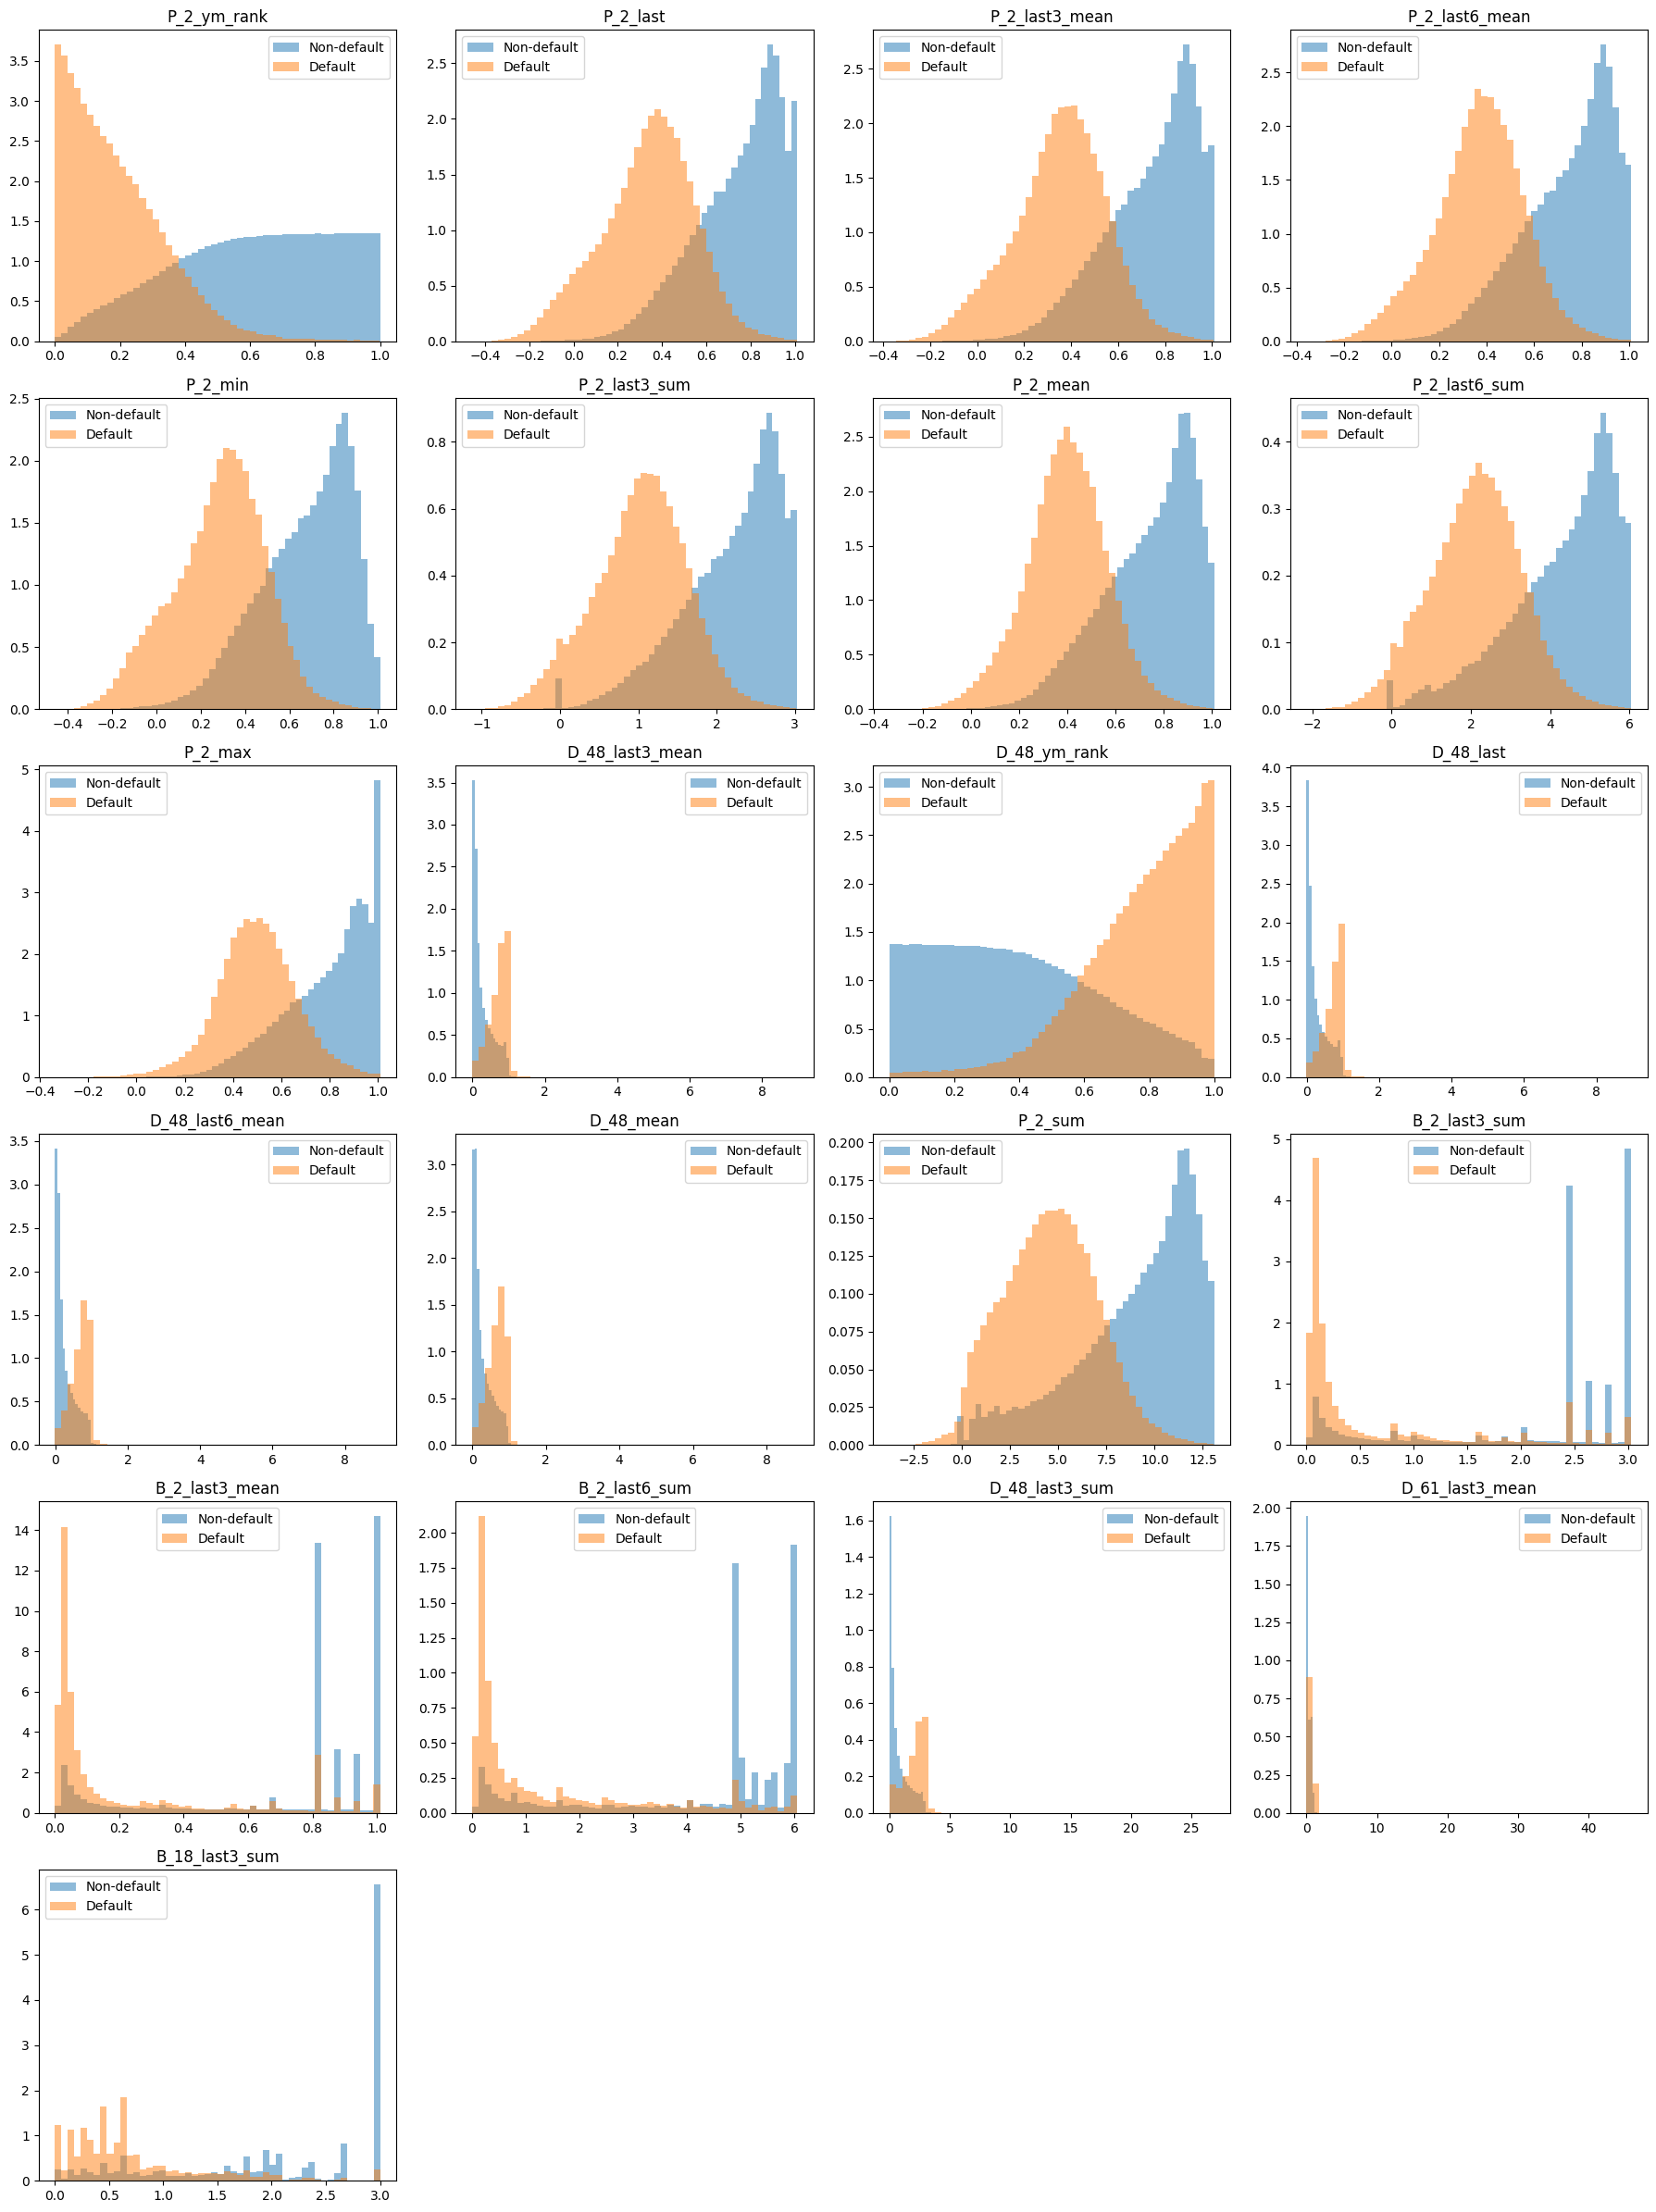

In [10]:
plot_top_features(train, cols_with_high_corr)